In [43]:
import numpy as np 
import pandas as pd 
import seaborn as sns

In [44]:
df = pd.read_csv('CollegePlacement.csv')[['IQ','CGPA','Projects_Completed','Placement']]

In [45]:
df.head()

,IQ,CGPA,Projects_Completed,Placement
0,107,6.28,4,No
1,97,5.37,0,No
2,109,5.83,1,No
3,122,5.75,1,No
4,96,7.69,2,No


In [62]:
df.shape

(10004, 4)

In [47]:
df.describe()

,IQ,CGPA,Projects_Completed
count,10000.000000,10000.000000,10000.000000
mean,99.471800,7.532379,2.513400
std,15.053101,1.470141,1.715959
min,41.000000,4.540000,0.000000
25%,89.000000,6.290000,1.000000
50%,99.000000,7.550000,3.000000
75%,110.000000,8.770000,4.000000
max,158.000000,10.460000,5.000000


C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_14992\2748678828.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Projects_Completed'])


<Axes: xlabel='Projects_Completed', ylabel='Density'>

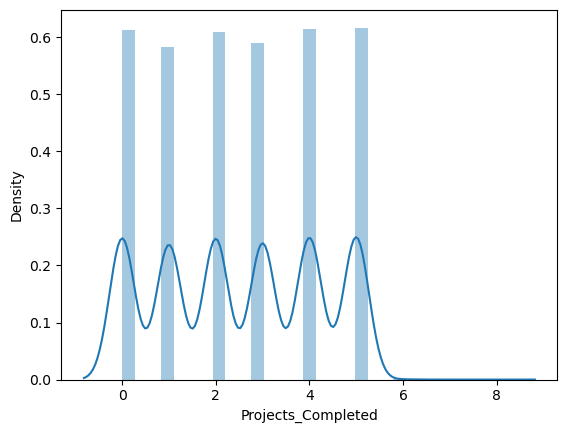

In [67]:
sns.distplot(df['Projects_Completed'])

<Axes: xlabel='Projects_Completed'>

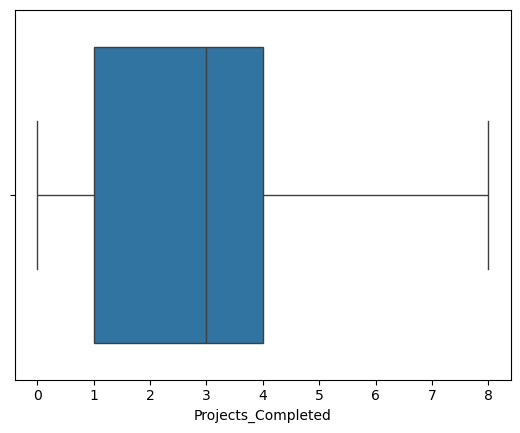

In [68]:
sns.boxplot(x=df['Projects_Completed'])

In [50]:
upperlimit = df['Projects_Completed'].quantile(0.99)
lowerlimit = df['Projects_Completed'].quantile(0.01)

In [51]:
upperlimit, lowerlimit

(5.0, 0.0)

In [52]:
df.loc[len(df)] = [70,5.0,6,'No']
df.loc[len(df)] = [45,8.0,6,'Yes']
df.loc[len(df)] = [100,5.0,6,'Yes']
df.loc[len(df)] = [5,90.0,8,'Yes']

In [53]:
# find Outliers

df[df['Projects_Completed'] > upperlimit]

,IQ,CGPA,Projects_Completed,Placement
10000,70,5.0,6,No
10001,45,8.0,6,Yes
10002,100,5.0,6,Yes
10003,5,90.0,8,Yes


In [60]:
# Trimming 

new_df = df[(df['Projects_Completed'] <= upperlimit) & (df['Projects_Completed'] >= lowerlimit)]

In [61]:
new_df.shape

(10000, 4)

In [63]:
# Capping

df2 = df.copy()

df2['Projects_Completed'] = np.where(df2['Projects_Completed'] > upperlimit, upperlimit,
                                    np.where(df2['Projects_Completed'] < lowerlimit, lowerlimit,df2['Projects_Completed']))

In [64]:
df2.shape

(10004, 4)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_14992\1373044930.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Projects_Completed'])


<Axes: xlabel='Projects_Completed', ylabel='Density'>

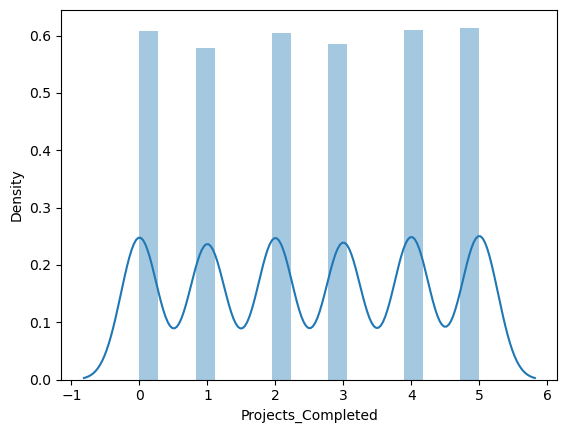

In [66]:
sns.distplot(df2['Projects_Completed'])